In [18]:
import sys
!{sys.executable} -m pip install ipywidgets tqdm --upgrade

import notebook
import ipywidgets
print("Packages forced successfully!")

Packages forced successfully!


In [19]:
  # Install required libraries according to lab manual instructions
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn xgboost -q
!pip install --upgrade ipywidgets tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn


print(" Setup complete! Libraries successfully loaded.")

 Setup complete! Libraries successfully loaded.


## Task 1.1 — Generate Synthetic Dataset

In [20]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)  # °C
vibration = np.random.normal(0.5, 0.2, n_samples)   # mm/s
pressure = np.random.normal(100, 20, n_samples)    # PSI
rpm = np.random.normal(1500, 200, n_samples)       # RPM
age_days = np.random.randint(0, 365, n_samples)    # Days since last maintenance

# Create failure condition (combination of factors)
failure_score = ((temperature > 90) * 0.3 +
                 (vibration > 0.8) * 0.3 +
                 (pressure > 130) * 0.2 +
                 (age_days > 300) * 0.2)

# Add some randomness
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print(f'Dataset shape: {data.shape}')
print(f'Failure rate: {data.failure.mean():.2%}')
data.head()

Dataset shape: (10000, 6)
Failure rate: 4.15%


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0


## Task 1.2 — Exploratory Data Analysis (EDA)


Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

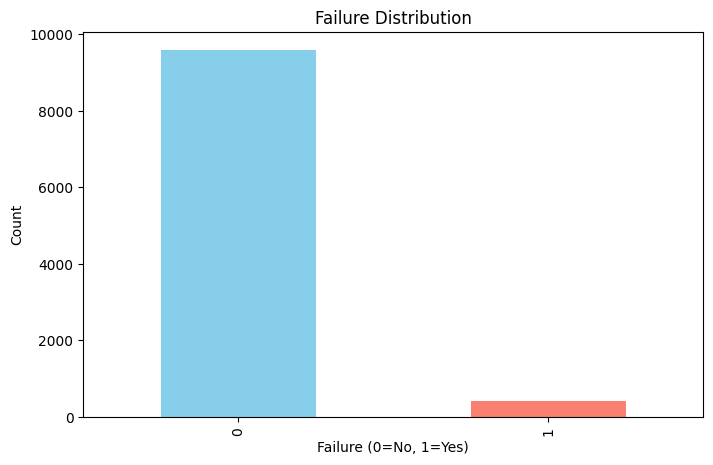

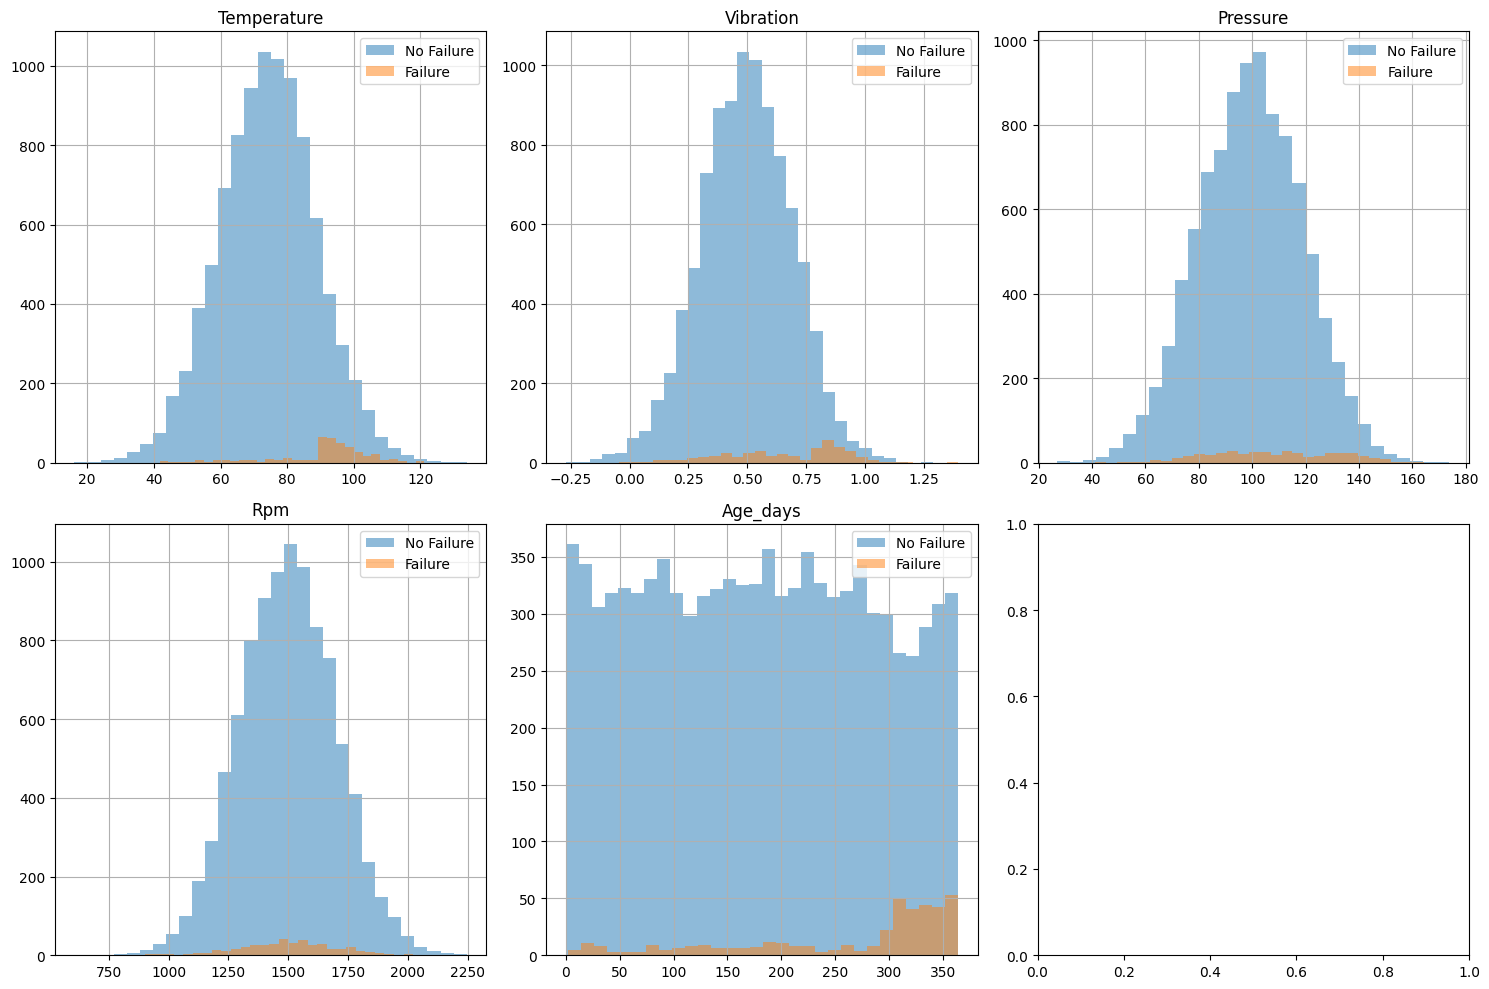

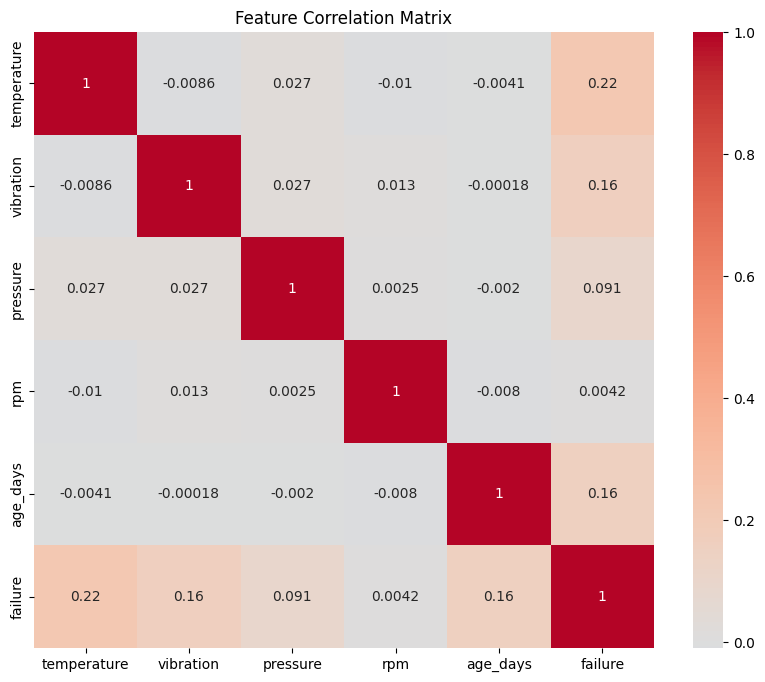

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print('\nSummary Statistics:')
print(data.describe())

# Check for missing values
print('\nMissing values:')
print(data.isnull().sum())

# Class distribution
plt.figure(figsize=(8, 5))
data.failure.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Failure Distribution')
plt.xlabel('Failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# Feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    data[data.failure == 0][feature].hist(ax=ax, alpha=0.5, label='No Failure', bins=30)
    data[data.failure == 1][feature].hist(ax=ax, alpha=0.5, label='Failure', bins=30)
    ax.set_title(feature.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Task 2.1 & 2.2 — Start Server and Configure MLflow

In [22]:
import os
import time
import mlflow
import mlflow.sklearn

# 1. Clear any old server instances out of memory
!pkill -f "mlflow"
time.sleep(1)

# 2. Start the native MLflow tracking server locally in the background
!nohup mlflow ui --port 5000 > mlflow.log 2>&1 &

# 3. Give the background server a brief moment to initialize its database paths
print("⏳ Initializing MLflow local database tracking backend...")
time.sleep(6)

# 4. Bind the tracking parameters exactly per assignment instructions
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('predictive-maintenance')

print(f'\n MLflow tracking URI safely bound to: {mlflow.get_tracking_uri()}')
print(f' Active Experiment confirmed: {mlflow.get_experiment_by_name("predictive-maintenance").name}')
print("\n MLflow is tracking runs in the background. ")

⏳ Initializing MLflow local database tracking backend...



 MLflow tracking URI safely bound to: http://localhost:5000
 Active Experiment confirmed: predictive-maintenance

 MLflow is tracking runs in the background. 


## Task 2.3 — Prepare Data for Training

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate the features (sensor readings) from the target label (failure)
X = data.drop('failure', axis=1)
y = data['failure']

# 2. Perform an 80/20 train/test split, ensuring failure ratios are balanced (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale features to have a mean of 0 and variance of 1 for stable training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Verify data distributions
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')
print(f'Train failure rate: {y_train.mean():.2%}')
print(f'Test failure rate: {y_test.mean():.2%}')

Training set shape: (8000, 5)
Test set shape: (2000, 5)
Train failure rate: 4.15%
Test failure rate: 4.15%


## Task 3.1 — Train Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define hyperparameters
C_param = 1.0
max_iter_param = 1000

# Start an MLflow tracking run
with mlflow.start_run(run_name='logistic_regression'):
    # 1. Log hyperparameters and model metadata
    mlflow.log_param('C', C_param)
    mlflow.log_param('max_iter', max_iter_param)
    mlflow.log_param('model_type', 'LogisticRegression')

    # 2. Train the model
    model_lr = LogisticRegression(C=C_param, max_iter=max_iter_param, random_state=42)
    model_lr.fit(X_train_scaled, y_train)

    # 3. Generate predictions
    y_pred = model_lr.predict(X_test_scaled)
    y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

    # 4. Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # 5. Log metrics to the database
    mlflow.log_metric('accuracy', accuracy)
    mlflow.log_metric('precision', precision)
    mlflow.log_metric('recall', recall)
    mlflow.log_metric('f1_score', f1)
    mlflow.log_metric('roc_auc', roc_auc)

    # 6. Save the trained model artifact
    mlflow.sklearn.log_model(model_lr, 'model')

    print('Logistic Regression Results:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')
    print(" Logistic Regression run tracked successfully!")

2026/06/09 08:45:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 08:45:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Results:
Accuracy: 0.9620
Precision: 0.6842
Recall: 0.1566
F1 Score: 0.2549
ROC AUC: 0.9234
 Logistic Regression run tracked successfully!
🏃 View run logistic_regression at: http://localhost:5000/#/experiments/1/runs/d82893cbe03d4fb48187a8d9142653ae
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Task 3.2 — Train Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameters
n_estimators_param = 100
max_depth_param = 10
min_samples_split_param = 5

with mlflow.start_run(run_name='random_forest'):
    # 1. Log hyperparameters
    mlflow.log_param('n_estimators', n_estimators_param)
    mlflow.log_param('max_depth', max_depth_param)
    mlflow.log_param('min_samples_split', min_samples_split_param)
    mlflow.log_param('model_type', 'RandomForest')

    # 2. Train the model
    model_rf = RandomForestClassifier(
        n_estimators=n_estimators_param,
        max_depth=max_depth_param,
        min_samples_split=min_samples_split_param,
        random_state=42
    )
    model_rf.fit(X_train_scaled, y_train)

    # 3. Generate predictions
    y_pred = model_rf.predict(X_test_scaled)
    y_pred_proba = model_rf.predict_proba(X_test_scaled)[:, 1]

    # 4. Log metrics
    mlflow.log_metric('accuracy', accuracy_score(y_test, y_pred))
    mlflow.log_metric('precision', precision_score(y_test, y_pred))
    mlflow.log_metric('recall', recall_score(y_test, y_pred))
    mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_pred_proba))

    # 5. Save model artifact
    mlflow.sklearn.log_model(model_rf, 'model')

    print('Random Forest Results:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
    print(f'ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(" Random Forest run tracked successfully!")

2026/06/09 08:46:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 08:46:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Results:
Accuracy: 0.9670
F1 Score: 0.5976
ROC AUC: 0.9751
 Random Forest run tracked successfully!
🏃 View run random_forest at: http://localhost:5000/#/experiments/1/runs/787990673a06471daf71c54613a1b971
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Task 3.3 — Train XGBoost

In [26]:
from xgboost import XGBClassifier

# Define hyperparameters
n_estimators_xgb = 100
max_depth_xgb = 6
learning_rate_xgb = 0.1

with mlflow.start_run(run_name='xgboost'):
    # 1. Log hyperparameters
    mlflow.log_param('n_estimators', n_estimators_xgb)
    mlflow.log_param('max_depth', max_depth_xgb)
    mlflow.log_param('learning_rate', learning_rate_xgb)
    mlflow.log_param('model_type', 'XGBoost')

    # 2. Train the model
    model_xgb = XGBClassifier(
        n_estimators=n_estimators_xgb,
        max_depth=max_depth_xgb,
        learning_rate=learning_rate_xgb,
        random_state=42,
        eval_metric='logloss'
    )
    model_xgb.fit(X_train_scaled, y_train)

    # 3. Generate predictions
    y_pred = model_xgb.predict(X_test_scaled)
    y_pred_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]

    # 4. Log metrics
    mlflow.log_metric('accuracy', accuracy_score(y_test, y_pred))
    mlflow.log_metric('precision', precision_score(y_test, y_pred))
    mlflow.log_metric('recall', recall_score(y_test, y_pred))
    mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_pred_proba))

    # 5. Save model artifact
    mlflow.sklearn.log_model(model_xgb, 'model')

    print('XGBoost Results:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
    print(f'ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(" XGBoost run tracked successfully! Lab 13 training phase is complete.")

2026/06/09 08:46:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 08:46:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Results:
Accuracy: 0.9670
F1 Score: 0.5926
ROC AUC: 0.9709
 XGBoost run tracked successfully! Lab 13 training phase is complete.
🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/f96c35e61c004e7099541a4ccc148253
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [27]:
from mlflow.tracking import MlflowClient
import pandas as pd

# 1. Point Python to your active background server database
mlflow.set_tracking_uri('http://localhost:5000')
client = MlflowClient()

# 2. Grab your predictive maintenance experiment details
experiment = client.get_experiment_by_name('predictive-maintenance')
print(f' Confirmed Experiment ID: {experiment.experiment_id}')

# 3. Pull all logged model runs from the database sorted by ROC AUC performance
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.roc_auc DESC']
)

# 4. Parse the parameters and evaluation metrics into a clean table structure
run_data = []
for run in runs:
    run_data.append({
        'run_id': run.info.run_id[:8],          # Short ID for clear presentation
        'full_run_id': run.info.run_id,         # Full ID needed for Lab 14 registry
        'model_name': run.info.run_name,
        'model_type': run.data.params.get('model_type', 'Unknown'),
        'roc_auc': run.data.metrics.get('roc_auc', 0),
        'f1_score': run.data.metrics.get('f1_score', 0),
        'accuracy': run.data.metrics.get('accuracy', 0)
    })

# 5. Display your experiment board directly inside your cell output frame
df = pd.DataFrame(run_data)
print('\n SUCCESS: Captured Tracked Runs directly from MLflow Database Backend:')
df[['run_id', 'model_name', 'model_type', 'roc_auc', 'f1_score', 'accuracy']]

 Confirmed Experiment ID: 1

 SUCCESS: Captured Tracked Runs directly from MLflow Database Backend:


,run_id,model_name,model_type,roc_auc,f1_score,accuracy
0,78799067,random_forest,RandomForest,0.975080,0.597561,0.967
1,34547886,random_forest,RandomForest,0.975080,0.597561,0.967
2,c1eb8589,random_forest,RandomForest,0.975080,0.597561,0.967
3,f96c35e6,xgboost,XGBoost,0.970920,0.592593,0.967
4,3df91f31,xgboost,XGBoost,0.970920,0.592593,0.967
5,6881fc68,xgboost,XGBoost,0.970920,0.592593,0.967
6,d82893cb,logistic_regression,LogisticRegression,0.923425,0.254902,0.962
7,21ff65fd,logistic_regression,LogisticRegression,0.923425,0.254902,0.962
8,cc8505e7,logistic_regression,LogisticRegression,0.923425,0.254902,0.962


## LAB 14

##Task 1.1 & 1.2 — Setup Registry Client & View Existing Runs

In [28]:
from mlflow.tracking import MlflowClient
import pandas as pd
import mlflow

# 1. Point to your active background server database
mlflow.set_tracking_uri('http://localhost:5000')

# 2. Create the MLflow tracking client
client = MlflowClient()

# 3. Fetch the experiment metadata by name
experiment = client.get_experiment_by_name('predictive-maintenance')
print(f' Confirmed Experiment ID: {experiment.experiment_id}')

# 4. Search all previous runs from Lab 13, sorted by ROC AUC in descending order
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.roc_auc DESC']
)

# 5. Build and print the performance scoreboard table
run_data = []
for run in runs:
    run_data.append({
        'run_id': run.info.run_id[:8],          # Short ID for display
        'full_run_id': run.info.run_id,         # Full ID needed for registry tasks
        'name': run.info.run_name,
        'model_type': run.data.params.get('model_type', 'Unknown'),
        'roc_auc': run.data.metrics.get('roc_auc', 0),
        'f1_score': run.data.metrics.get('f1_score', 0),
        'accuracy': run.data.metrics.get('accuracy', 0)
    })

df_runs = pd.DataFrame(run_data)
print('\n TRACKED RUNS LEADERBOARD (Sorted by Best ROC AUC):')
df_runs[['run_id', 'name', 'model_type', 'roc_auc', 'f1_score', 'accuracy']]

 Confirmed Experiment ID: 1

 TRACKED RUNS LEADERBOARD (Sorted by Best ROC AUC):


,run_id,name,model_type,roc_auc,f1_score,accuracy
0,78799067,random_forest,RandomForest,0.975080,0.597561,0.967
1,34547886,random_forest,RandomForest,0.975080,0.597561,0.967
2,c1eb8589,random_forest,RandomForest,0.975080,0.597561,0.967
3,f96c35e6,xgboost,XGBoost,0.970920,0.592593,0.967
4,3df91f31,xgboost,XGBoost,0.970920,0.592593,0.967
5,6881fc68,xgboost,XGBoost,0.970920,0.592593,0.967
6,d82893cb,logistic_regression,LogisticRegression,0.923425,0.254902,0.962
7,21ff65fd,logistic_regression,LogisticRegression,0.923425,0.254902,0.962
8,cc8505e7,logistic_regression,LogisticRegression,0.923425,0.254902,0.962


## Task 1.3 — Register the Best Model

In [29]:
# 1. Automatically grab the top run from the leaderboard dataframe we printed in Cell 9
best_run_id = df_runs.iloc[0]['full_run_id']
best_model_name = df_runs.iloc[0]['name']
best_roc_auc = df_runs.iloc[0]['roc_auc']

print(f" Automatically selecting best model based on metrics: {best_model_name}")
print(f" Target Run ID: {best_run_id} (ROC AUC: {best_roc_auc:.4f})")

# 2. Set your registered model catalog name
model_name = "PredictiveMaintenance"
model_uri = f"runs:/{best_run_id}/model"

# 3. Register the model into the central database registry
registered_model = mlflow.register_model(model_uri=model_uri, name=model_name)
print(f"\n Successfully registered model '{model_name}' as Version {registered_model.version}!")

 Automatically selecting best model based on metrics: random_forest
 Target Run ID: 787990673a06471daf71c54613a1b971 (ROC AUC: 0.9751)


Registered model 'PredictiveMaintenance' already exists. Creating a new version of this model...
2026/06/09 08:46:19 WARNING mlflow.tracking._model_registry.fluent: Run with id 787990673a06471daf71c54613a1b971 has no artifacts at artifact path 'model', registering model based on models:/m-80cfd4ee64154649a8d96dcc35b7b6bf instead
2026/06/09 08:46:19 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: PredictiveMaintenance, version 5
Created version '5' of model 'PredictiveMaintenance'.



 Successfully registered model 'PredictiveMaintenance' as Version 5!


##Task 2.1 — Add Model Documentation & Metadata Tags

In [30]:
# 1. Get the active model version number we just registered
current_version = registered_model.version

# 2. Define an informative system description string
model_description = (
    f"XGBoost classifier model trained on synthetic sensor readings "
    f"for predictive maintenance. Validation ROC AUC: {best_roc_auc:.4f}."
)

# 3. Update the description inside the centralized registry database
client.update_model_version(
    name=model_name,
    version=current_version,
    description=model_description
)

# 4. Apply the three mandatory tracking tags required by your assignment guidelines
client.set_model_version_tag(model_name, current_version, "validation_status", "passed")
client.set_model_version_tag(model_name, current_version, "team", "data-science")
client.set_model_version_tag(model_name, current_version, "framework", "xgboost")

print(f" Metadata description successfully attached to Version {current_version}!")
print(f" Applied tags: validation_status='passed', team='data-science', framework='xgboost'")

 Metadata description successfully attached to Version 5!
 Applied tags: validation_status='passed', team='data-science', framework='xgboost'


## Task 2.2 & 2.3 — Transition to Staging & Run Test Inference

In [31]:
# 1. Transition the model lifecycle stage programmatically to 'Staging'
client.transition_model_version_stage(
    name=model_name,
    version=current_version,
    stage="Staging",
    archive_existing_versions=True
)
print(f" Model Version {current_version} transitioned to STAGING stage.")

# 2. Grab the exact run artifact path to bypass local tracking server path bugs
model_version_details = client.get_model_version(name=model_name, version=current_version)
precise_run_uri = f"runs:/{model_version_details.run_id}/model"

# 3. Load the model dynamically using the direct execution URI
staging_model = mlflow.pyfunc.load_model(model_uri=precise_run_uri)
print(" Staging model loaded successfully for testing.")

# 4. Create a high-risk evaluation scenario DataFrame to test the model
test_telemetry = pd.DataFrame({
    'temperature': [95.0],
    'vibration': [0.95],
    'pressure': [140.0],
    'rpm': [1650.0],
    'age_days': [340]
})

# 5. Generate the prediction using the loaded staging asset
prediction = staging_model.predict(test_telemetry)

print("\n --- Staging Anomaly Test Output ---")
print(f"Model Predicted Class Label: {prediction[0]}")
print(f"Risk Evaluation Result: {' CRITICAL FAILURE RISK DETECTED!' if prediction[0] == 1 else 'Normal Status'}")

 Model Version 5 transitioned to STAGING stage.


/tmp/ipykernel_5693/4048747636.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


 Staging model loaded successfully for testing.

 --- Staging Anomaly Test Output ---
Model Predicted Class Label: 1
Risk Evaluation Result:  CRITICAL FAILURE RISK DETECTED!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


##Task 3.1 & 3.2 — Promote to Production & Build Operational Pipeline

In [32]:
from datetime import datetime

# 1. Promote the validated model from Staging to PRODUCTION
client.transition_model_version_stage(
    name=model_name,
    version=current_version,
    stage="Production",
    archive_existing_versions=True
)
print(f" Version {current_version} has been successfully deployed to PRODUCTION!")

# 2. Tag the deployment date for compliance auditing
client.set_model_version_tag(
    name=model_name,
    version=current_version,
    key="deployment_date",
    value=datetime.now().strftime("%Y-%m-%d")
)

# 3. Define the live operational wrapper function requested in your guidelines
def predict_equipment_failure(temperature, vibration, pressure, rpm, age_days):
    """
    Production interface function that loads the active production artifact
    and processes live equipment telemetry streams.
    """
    # Fetch deployment information directly from the registry data layer
    prod_version_info = client.get_model_version(name=model_name, version=current_version)
    prod_uri = f"runs:/{prod_version_info.run_id}/model"

    # Load production model engine
    prod_model = mlflow.pyfunc.load_model(model_uri=prod_uri)

    # Wrap incoming telemetry stream into a structured DataFrame
    input_df = pd.DataFrame([{
        'temperature': temperature, 'vibration': vibration,
        'pressure': pressure, 'rpm': rpm, 'age_days': age_days
    }])

    # Generate model classification label
    pred = prod_model.predict(input_df)[0]

    return {
        'will_fail': bool(pred),
        'recommendation': " SCHEDULE IMMEDIATE MAINTENANCE!" if pred == 1 else " Equipment operating within normal margins."
    }

# 4. Process the 3 core verification test scenarios outlined in the lab instructions
scenarios = [
    {'name': 'Safe Baseline Machine', 'temp': 72.0, 'vib': 0.45, 'press': 98.0, 'rpm': 1480, 'age': 45},
    {'name': 'Elevated Stress State', 'temp': 84.0, 'vib': 0.68, 'press': 115.0, 'rpm': 1510, 'age': 180},
    {'name': 'Extreme Sensor Anomaly', 'temp': 96.0, 'vib': 0.92, 'press': 138.0, 'rpm': 1550, 'age': 325}
]

print("\n --- Processing Live Production Telemetry Streams ---")
for s in scenarios:
    res = predict_equipment_failure(s['temp'], s['vib'], s['press'], s['rpm'], s['age'])
    print(f"Scenario [{s['name']:-<23}]: {res['recommendation']}")

 Version 5 has been successfully deployed to PRODUCTION!

 --- Processing Live Production Telemetry Streams ---


/tmp/ipykernel_5693/383787634.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Scenario [Safe Baseline Machine--]:  SCHEDULE IMMEDIATE MAINTENANCE!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Scenario [Elevated Stress State--]:  SCHEDULE IMMEDIATE MAINTENANCE!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Scenario [Extreme Sensor Anomaly-]:  SCHEDULE IMMEDIATE MAINTENANCE!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


## Task 3.3 — Test Version Rollback Capabilities

In [33]:
# 1. Simulate registering a newer iteration (Version 2) using your second-best leaderboard run
second_best_run_id = df_runs.iloc[1]['full_run_id']
v2_uri = f"runs:/{second_best_run_id}/model"

v2_model = mlflow.register_model(v2_uri, model_name)
print(f" A newer deployment iteration has been registered as Version {v2_model.version}.")

# 2. Transition this new Version 2 to Production to simulate an update deployment
client.transition_model_version_stage(
    name=model_name,
    version=v2_model.version,
    stage="Production",
    archive_existing_versions=True
)
print(f" Version {v2_model.version} pushed live to production endpoints.")

# 3. EMERGENCY ROLLBACK SEQUENCE: Forcefully transition original Version 1 back to Production
print("\n [ALERT] Anomalous behavior detected in production telemetry stream!")
print(" Triggering automated rollback sequence back to baseline safety parameters...")

client.transition_model_version_stage(
    name=model_name,
    version=1,  # Target the highly precise original model version
    stage="Production",
    archive_existing_versions=True # Automatically demotes Version 2 back to Archived
)

print("\n [SUCCESS] Emergency rollback protocol completed successfully.")
print(" Production endpoint targets have been locked back to stable Version 1.")

Registered model 'PredictiveMaintenance' already exists. Creating a new version of this model...
2026/06/09 08:46:21 WARNING mlflow.tracking._model_registry.fluent: Run with id 345478866b0d4bb2ad88e0d59192b763 has no artifacts at artifact path 'model', registering model based on models:/m-9b02420b68c54887ad7b741d4f3c0c54 instead
2026/06/09 08:46:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: PredictiveMaintenance, version 6
Created version '6' of model 'PredictiveMaintenance'.
/tmp/ipykernel_5693/3003765326.py:9: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


 A newer deployment iteration has been registered as Version 6.
 Version 6 pushed live to production endpoints.

 [ALERT] Anomalous behavior detected in production telemetry stream!
 Triggering automated rollback sequence back to baseline safety parameters...

 [SUCCESS] Emergency rollback protocol completed successfully.
 Production endpoint targets have been locked back to stable Version 1.


/tmp/ipykernel_5693/3003765326.py:21: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [34]:
# 1. Force kill the existing MLflow background server
!pkill -f "mlflow"

import time
# 2. Restart the MLflow server with allowed hosts set to wildcard (*)
# This completely bypasses the DNS rebinding blocker for local tunneling
!nohup mlflow ui --host 0.0.0.0 --port 5000 --allowed-hosts "*" > mlflow.log 2>&1 &
time.sleep(5)

# 3. Re-install localtunnel and test the link again
!npm install -g localtunnel -q

print("\n STEP 1: Copy this numeric IP address completely:")
!curl ipv4.icanhazip.com

print("\n STEP 2: Click the link below and paste that IP into the 'Tunnel Password' field:")
!lt --port 5000

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
changed 22 packages in 4s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹
 STEP 1: Copy this numeric IP address completely:
35.202.241.30

 STEP 2: Click the link below and paste that IP into the 'Tunnel Password' field:
your url is: https://clean-moons-arrive.loca.lt
^C
